In [1]:
!pip install yfinance scikit-learn matplotlib pandas numpy

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# You can change stock here: AAPL → TSLA, MSFT, etc.
stock_symbol = "AAPL"

df = yf.download(stock_symbol, start="2020-01-01", end="2025-01-01")

df.head()

/tmp/ipykernel_23440/3973860084.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_symbol, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [4]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Shift Close column to create prediction target
df['Target'] = df['Close'].shift(-1)

# Drop last row (NaN)
df = df.dropna()

df.head()

Price,Open,High,Low,Close,Volume,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,71.409778,72.460776,71.156674,72.400513,135480400,71.696625
2020-01-03,71.629130,72.455943,71.472447,71.696625,146322800,72.267944
2020-01-06,70.819216,72.306514,70.568518,72.267944,118387200,71.928062
2020-01-07,72.277586,72.533103,71.708703,71.928062,108872000,73.085106
2020-01-08,71.631552,73.386423,71.631552,73.085106,132079200,74.637512


In [5]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [8]:
predictions = model.predict(X_test)

In [9]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 9.620178094077133
Root Mean Squared Error: 3.101641193638802


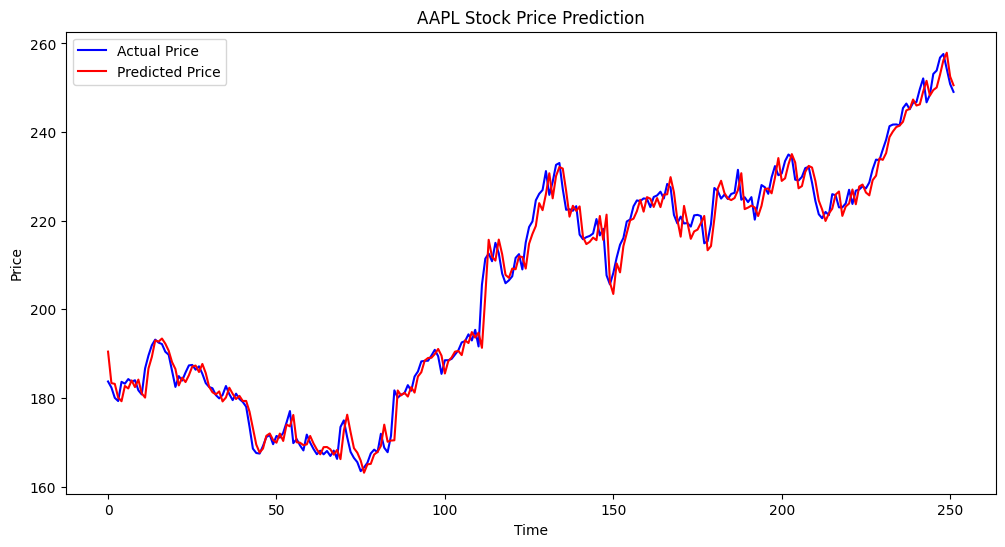

In [10]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price", color="blue")
plt.plot(predictions, label="Predicted Price", color="red")

plt.title(f"{stock_symbol} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()